[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polsitoooo/Ingenieria-Del-Conocimiento/blob/main/Tareas_Ejercicios/Semana4/modelos_clasificacion_PolmarBrice%C3%B1o__II_resuelto%28Dataset%20diabete_india%29.ipynb)


## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [2]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


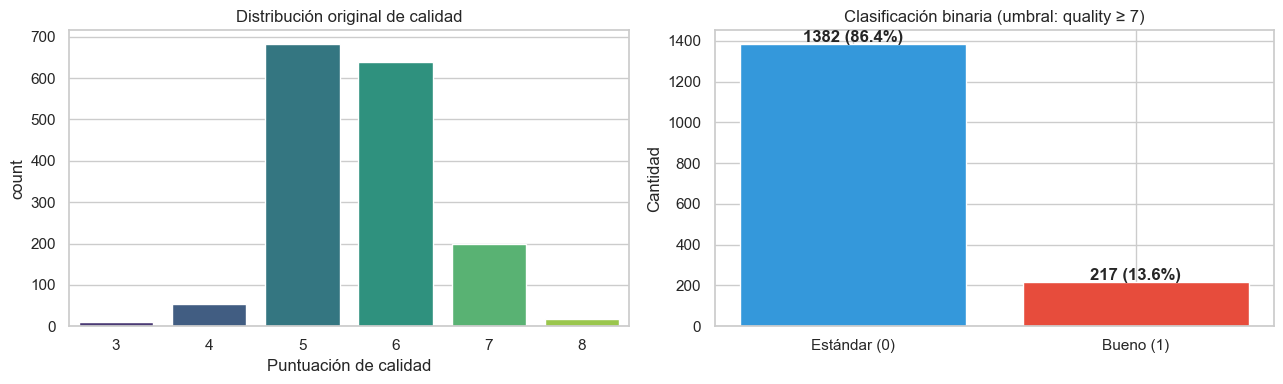


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [3]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [4]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


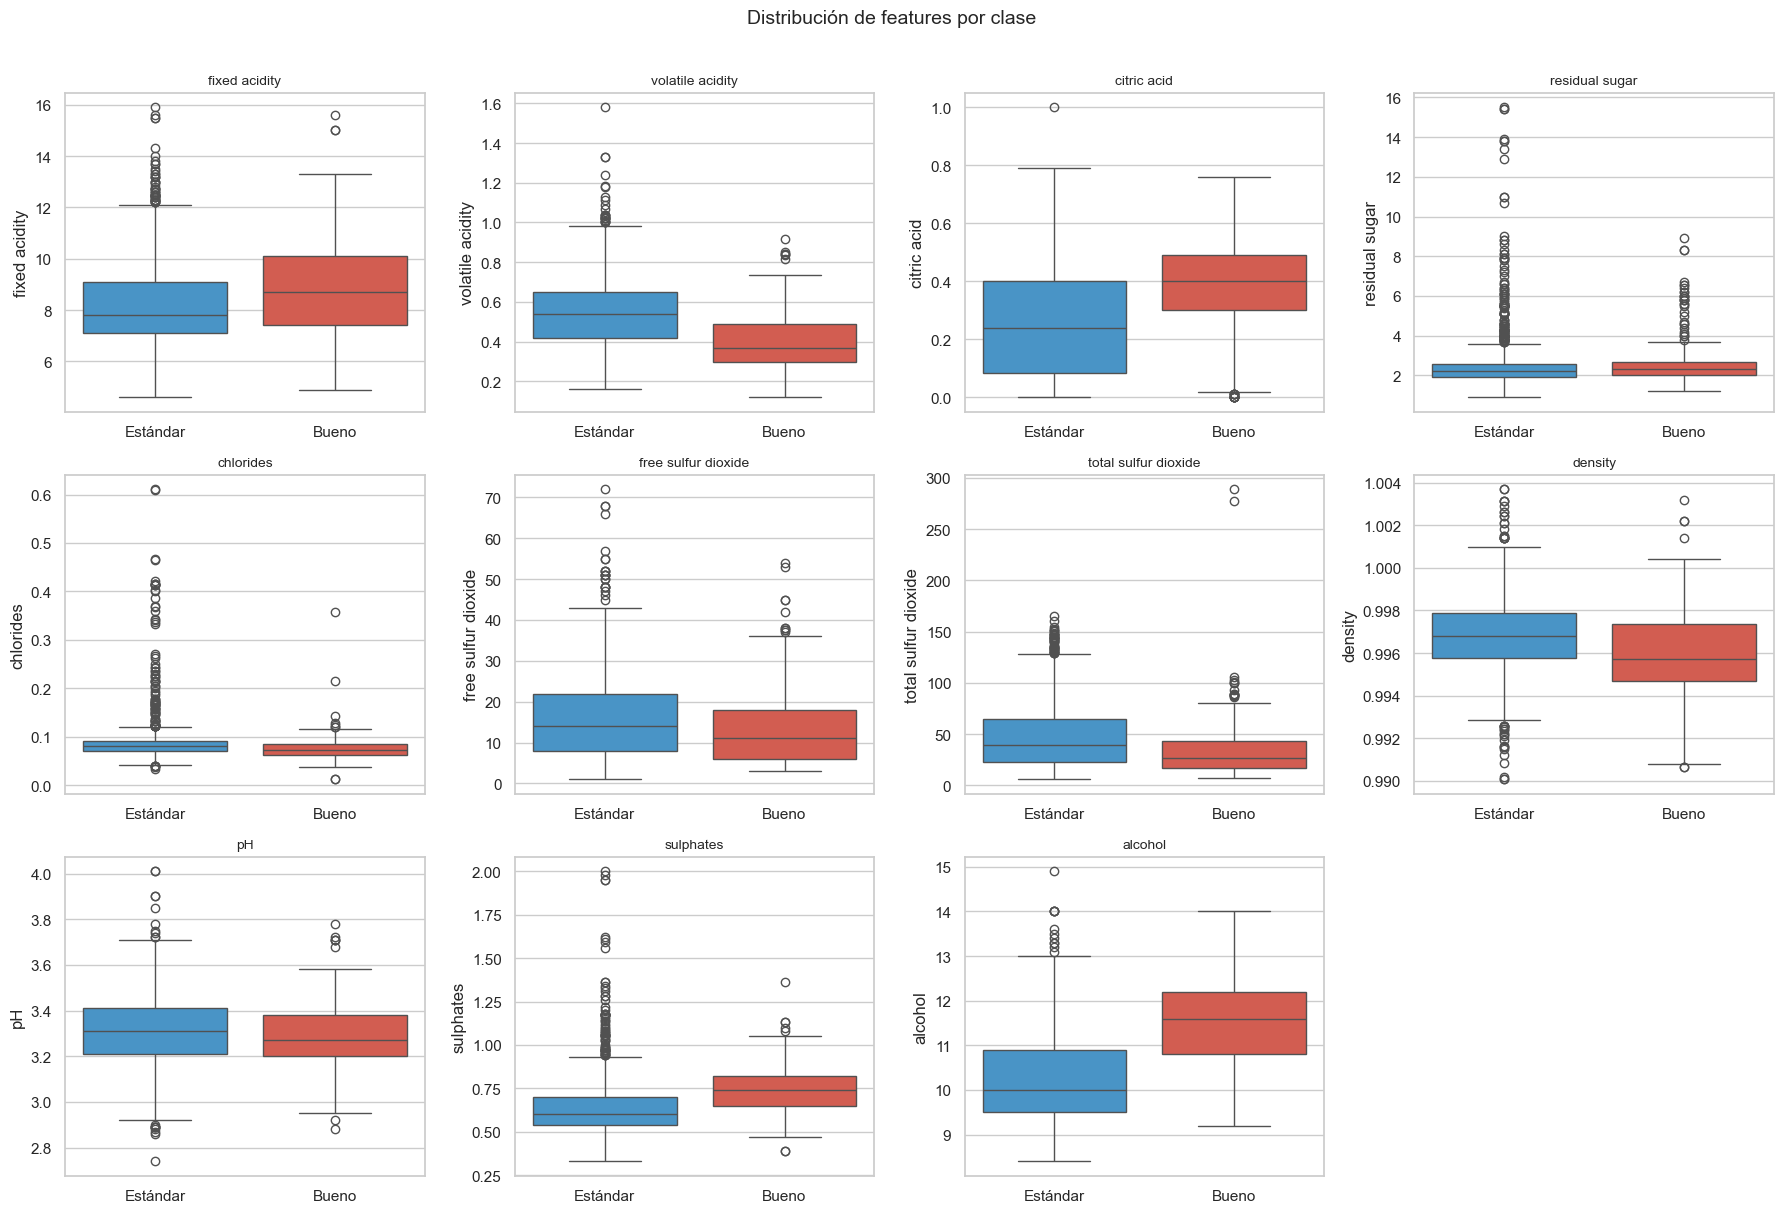

In [5]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

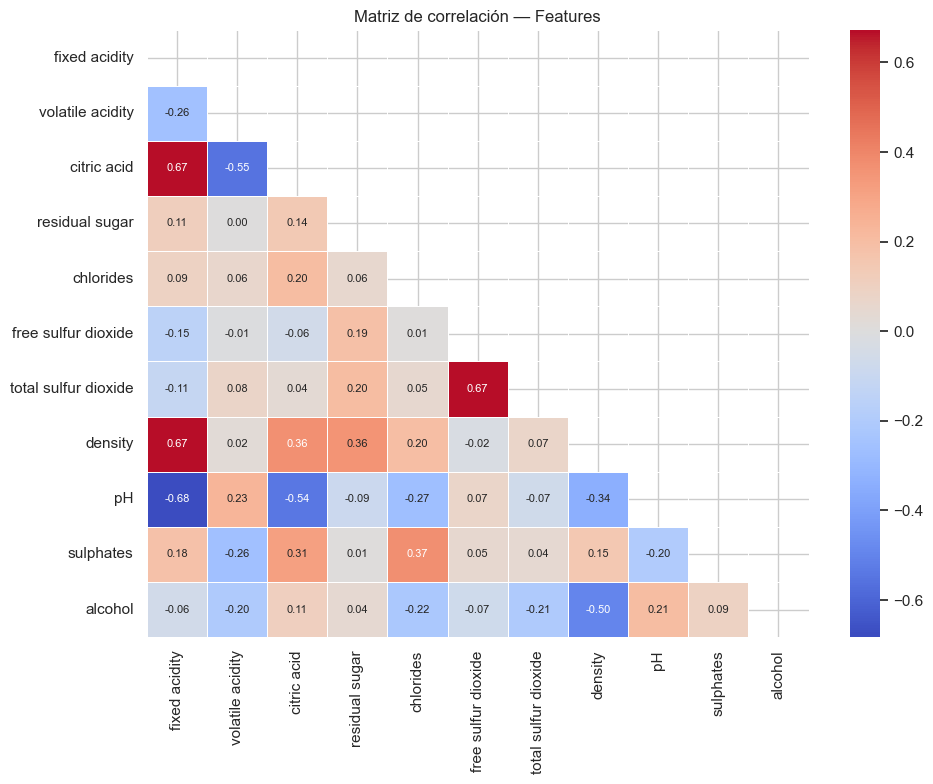

In [6]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [8]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


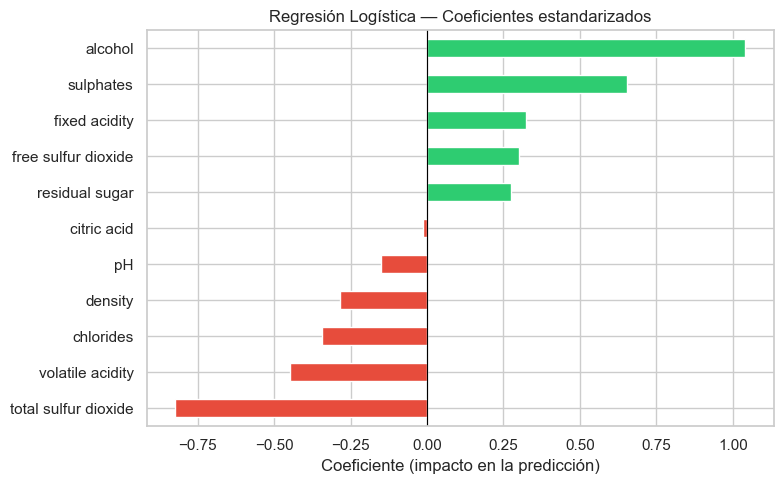


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [10]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [11]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


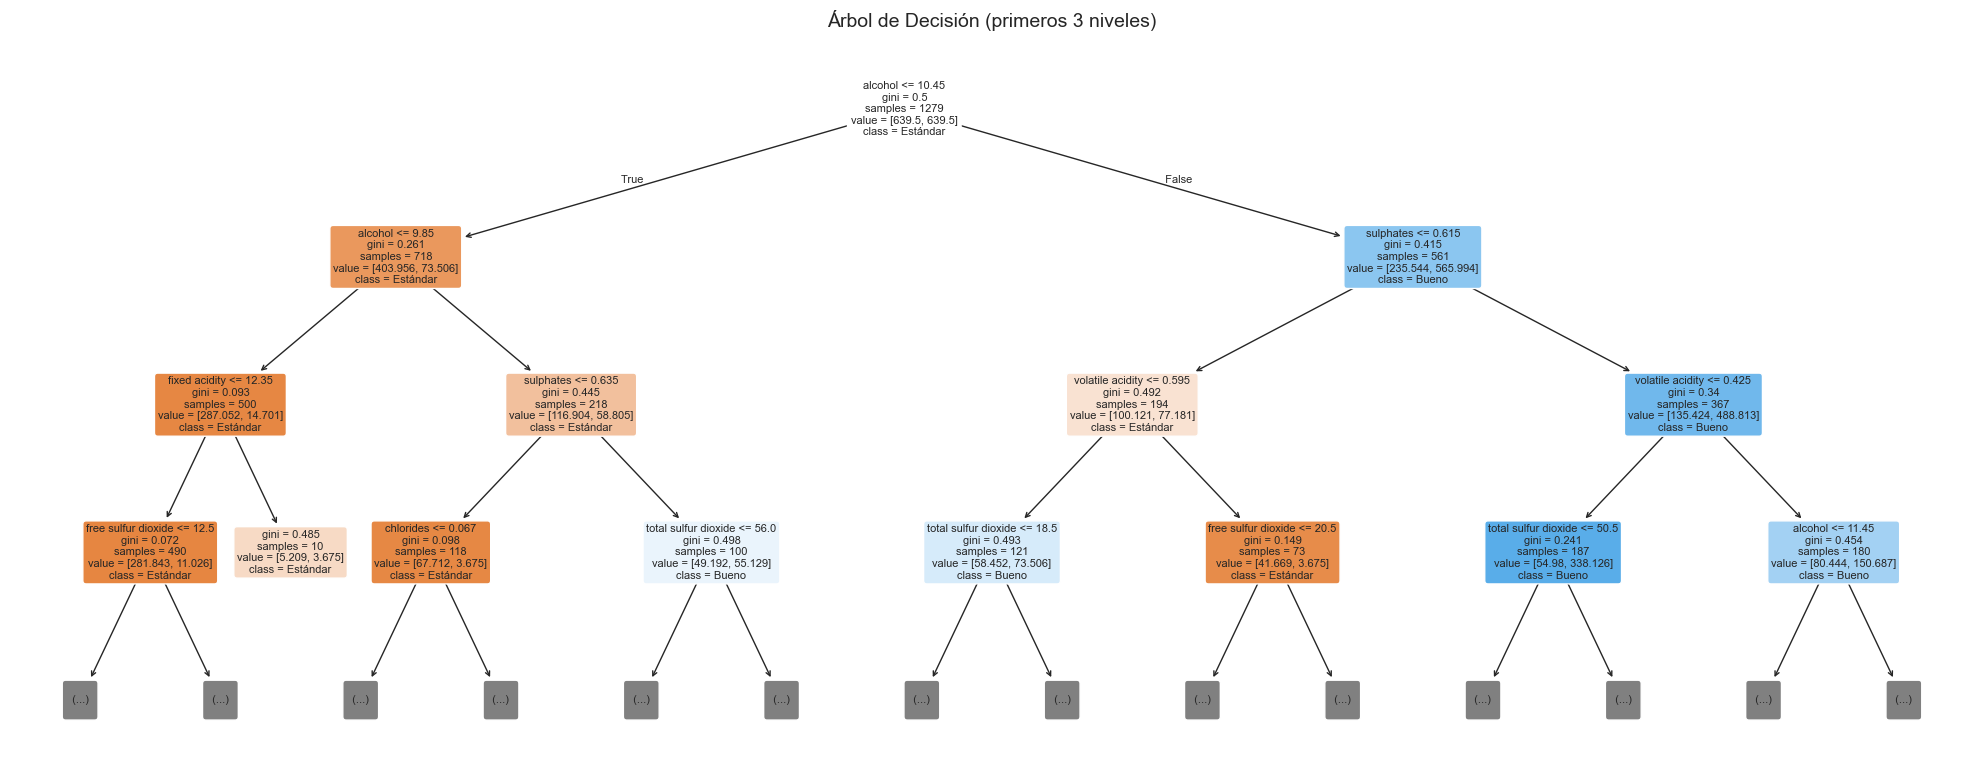

In [12]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

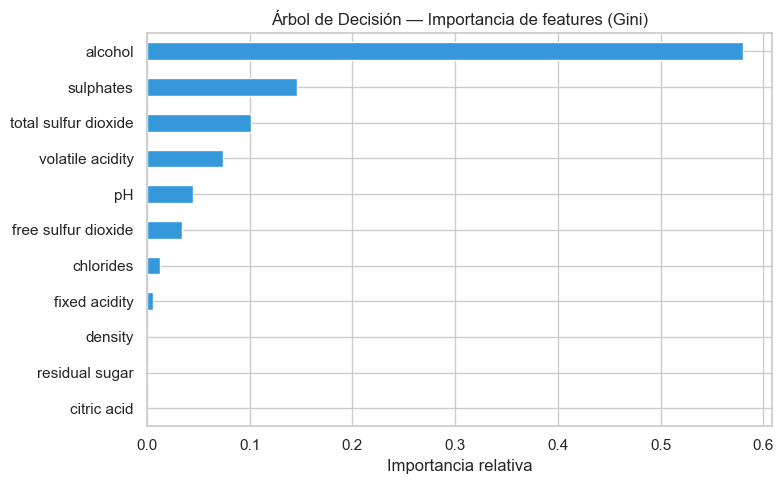

In [13]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

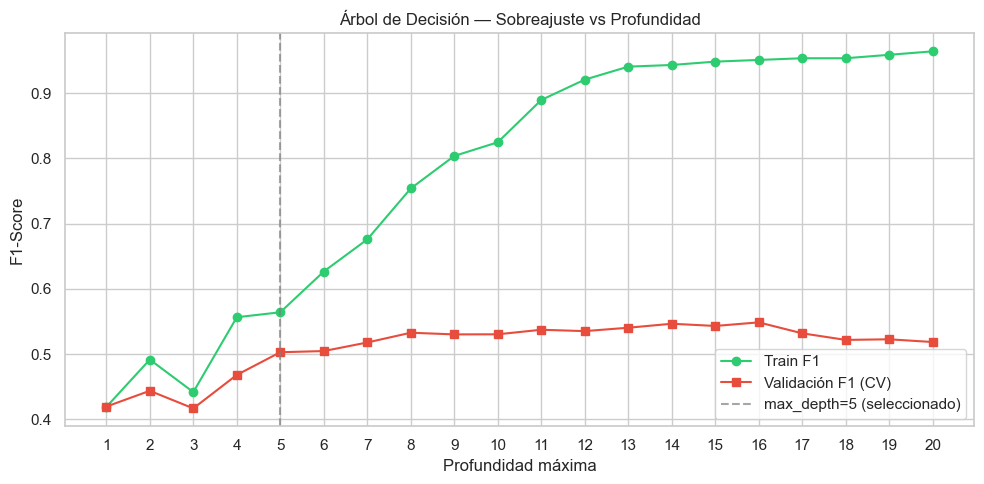

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [14]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [15]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [16]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [17]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

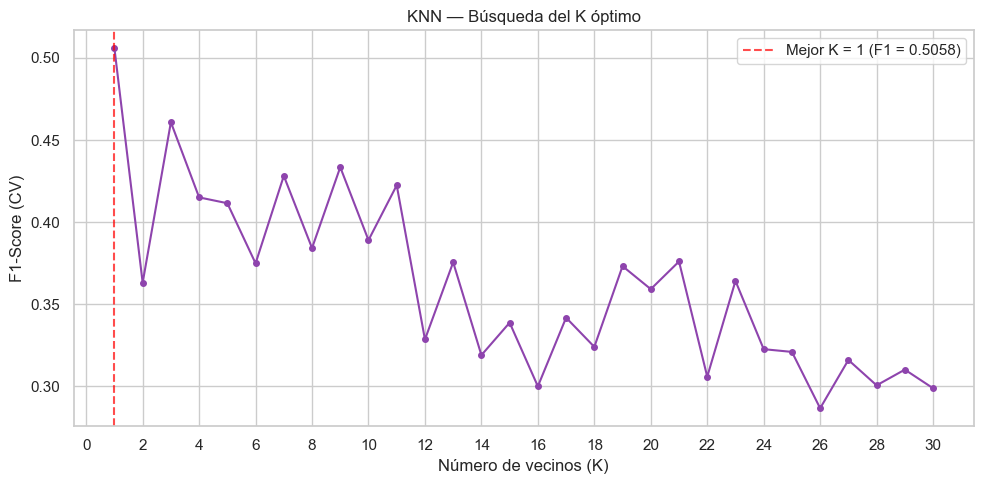

K óptimo: 1


In [18]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [19]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [20]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


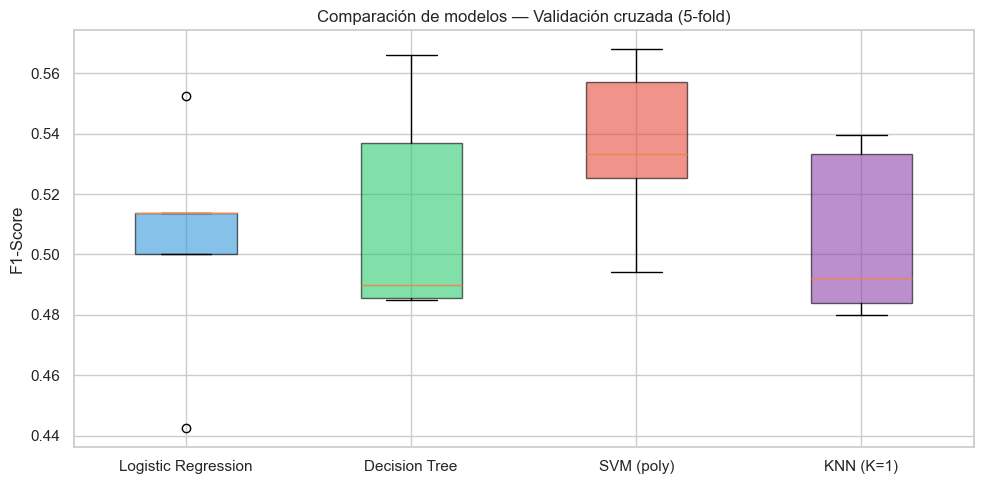

In [21]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

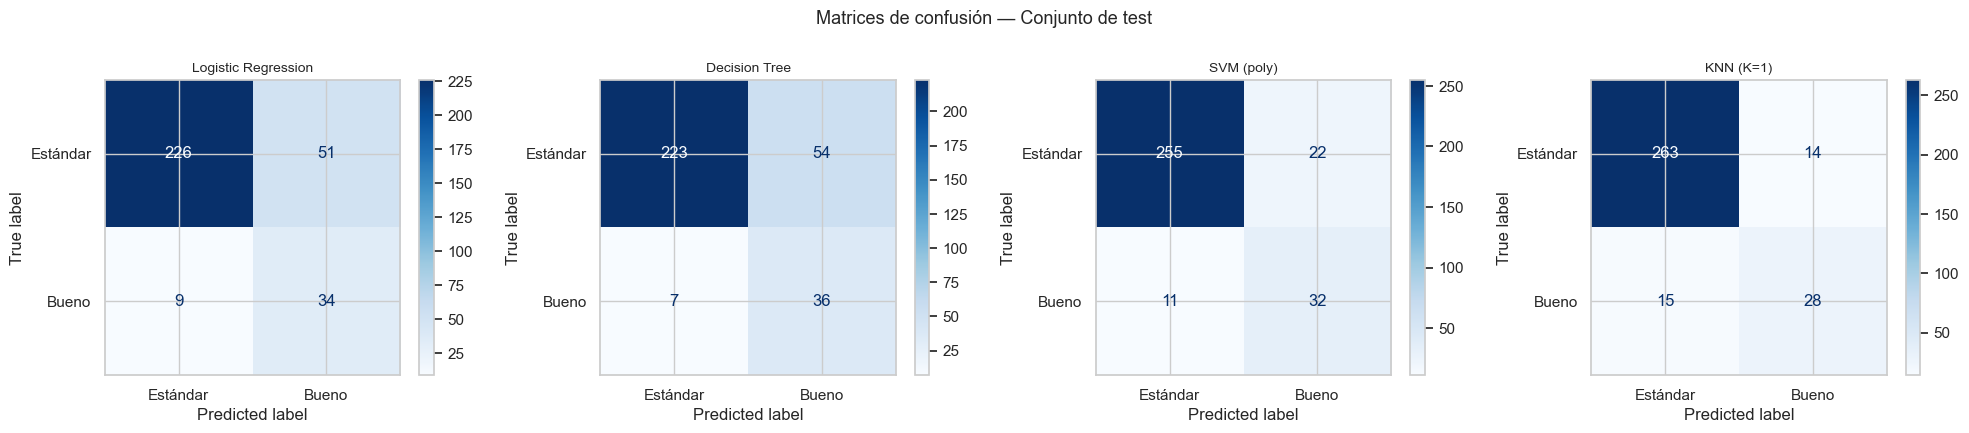

In [22]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

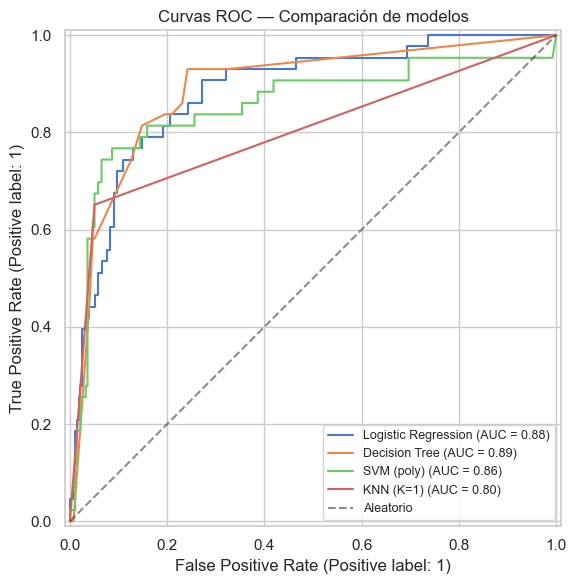

In [23]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
##  Soluciones a los ejercicios propuestos por el Ingeniero  (26/09/26)
##  Alumno: Briceño Carrión Polmar Yacid 
(Todo el proceso lo ire documentando con los #s)


### Ejercicio 1 — GridSearchCV para SVM

Se realiza una búsqueda exhaustiva de hiperparámetros para el SVM combinando `C`, `gamma` y `kernel` (se excluye `linear`, que no usa `gamma`, ya que la consigna solo pide `rbf` y `poly`). Se optimiza sobre `f1` usando el mismo esquema de validación cruzada (`StratifiedKFold`, 5 folds) que el resto del notebook, para que la comparación con el SVM base sea justa.

In [ ]:
# 1 Búsqueda de hiperparámetros con GridSearchCV  SVM = (Support Vector Machine...)
pipe_svm_grid = Pipeline([
    ('scaler', StandardScaler()),  #Media = 0 y Varianza = 1 (Crítico para modelos SVM)
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True))
])

param_grid = {
    'clf__C': [0.1, 1, 10, 100], #Controla la penalizacion de errores
    'clf__gamma': ['scale', 'auto', 0.01, 0.1], #Define la radio de influencia de un solo ejemplo de entrenamiento
    'clf__kernel': ['rbf', 'poly'] #Tipo de función de kernel para proyectar los datos a dimensiones superiores
}

grid_search = GridSearchCV(   #Se realiza la busqueda y el entrenamiento
    pipe_svm_grid, param_grid, scoring='f1', cv=cv, n_jobs=-1, refit=True
)
grid_search.fit(X_train, y_train) #Ejecuta la busqueda en paralelo sobre los datos de entrenamiento

print(f'Combinaciones evaluadas: {len(grid_search.cv_results_["params"])}') 
print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F1 (CV): {grid_search.best_score_:.4f}')

Combinaciones evaluadas: 32
Mejores hiperparámetros: {'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Mejor F1 (CV): 0.5450


            Modelo    F1 CV  F1 Test
   SVM base (poly) 0.535513 0.659794
SVM + GridSearchCV 0.545009 0.642202


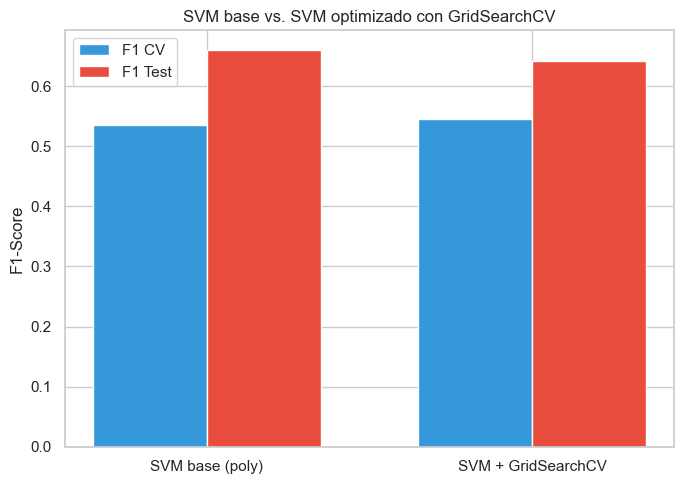

In [26]:
# 1.2  Comparación contra el SVM base de la sesión
best_svm_grid = grid_search.best_estimator_ #Extrae el pipeline ganador que reentreno GridSearchCv usando la mejor combinacion de hiperparametros
y_pred_svm_grid = best_svm_grid.predict(X_test) #Genera las predicciones para el conjunto de prueba independiente
f1_test_grid = f1_score(y_test, y_pred_svm_grid) #Calcula el F1-Score real sobre los datos de prueba para medir la capacidad de generalización del modelo optimizado.

comparison_ex1 = pd.DataFrame({    #Construimos la tabla comparativa
    'Modelo':  [f'SVM base ({best_kernel})', 'SVM + GridSearchCV'],
    'F1 CV':   [scores_svm.mean(), grid_search.best_score_],
    'F1 Test': [f1_score(y_test, y_pred_svm), f1_test_grid]
})
print(comparison_ex1.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, comparison_ex1['F1 CV'], width, label='F1 CV', color='#3498db')
ax.bar(x + width/2, comparison_ex1['F1 Test'], width, label='F1 Test', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(comparison_ex1['Modelo'])
ax.set_ylabel('F1-Score')
ax.set_title('SVM base vs. SVM optimizado con GridSearchCV')
ax.legend()
plt.tight_layout()
plt.show()

**Análisis del Ejercicio 1**

- `GridSearchCV` encuentra una combinación de `C`, `gamma` y `kernel` con un F1 de validación cruzada ligeramente **superior** al del SVM base (que solo probaba tres kernels con sus valores por defecto). La mejora es real pero modesta: el espacio de búsqueda ya estaba cerca de la región óptima.
- Nótese que la mejora en **CV** no siempre se traduce, en la misma magnitud, en una mejora en **test**: esto es normal y recuerda que el CV score es un estimador (con varianza) del rendimiento real, no un valor exacto. Por eso el conjunto de test —que no participó en la búsqueda de hiperparámetros— sigue siendo el juez final.
- Un `GridSearchCV` con esta grilla (4 × 4 × 2 = 32 combinaciones × 5 folds = 160 ajustes de SVM) ya es costoso computacionalmente; para grillas más grandes conviene `RandomizedSearchCV` o una búsqueda bayesiana (`Optuna`, `scikit-optimize`).

### Ejercicio 2 — Clasificación multiclase

Ahora se entrena directamente sobre la variable original `quality` (enteros 3–8, seis clases), sin binarizar. El desbalance es mucho más severo que en el problema binario: las clases extremas (3 y 8) tienen solo 10 y 18 muestras respectivamente, mientras que las clases centrales (5 y 6) concentran más del 80 % de los datos.

In [27]:
# 2.1  Preparación del target multiclase
y_multi = df['quality'].copy() #Crea una copia independiente de la columna quality
print('Distribución de clases (multiclase):')
print(y_multi.value_counts().sort_index()) #Cuenta la cantidad de observaciones por cada clase/categoría disponible. and Ordena los resultados

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split( #Division estratificada
    X, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi #20% para test, 80% para train, Semilla aleatoria, Muestreo Estratificado
)
print(f'\nTrain: {X_train_m.shape[0]} muestras  |  Test: {X_test_m.shape[0]} muestras')

Distribución de clases (multiclase):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Train: 1279 muestras  |  Test: 320 muestras


In [28]:
# 2.2  Entrenamiento de los 4 modelos (multiclase)
# Se reutilizan el kernel y el K óptimos hallados en la versión binaria del problema
pipe_lr_m = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])
pipe_lr_m.fit(X_train_m, y_train_m) #Regresión Logístic

pipe_dt_m = Pipeline([ #Árbol de Decisión
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                    class_weight='balanced', random_state=RANDOM_STATE))
])
pipe_dt_m.fit(X_train_m, y_train_m)

pipe_svm_m = Pipeline([   #SVM - Máquina de Vectores de Soporte
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE))
])
pipe_svm_m.fit(X_train_m, y_train_m)

pipe_knn_m = Pipeline([   #KNN - K-Vecinos Más Cercanos
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn_m.fit(X_train_m, y_train_m)

models_multi = { #Generación de Predicciones
    'Logistic Regression':   pipe_lr_m.predict(X_test_m),
    'Decision Tree':         pipe_dt_m.predict(X_test_m),
    f'SVM ({best_kernel})':  pipe_svm_m.predict(X_test_m),
    f'KNN (K={best_k})':     pipe_knn_m.predict(X_test_m),
}
print('Modelos multiclase entrenados.')

Modelos multiclase entrenados.


In [29]:
# 2.3  Comparación de métricas F1 (macro / micro / weighted)
summary_multi = []
for name, y_pred in models_multi.items():#Bucle de Evaluación, Itera sobre el diccionario models_multi, extrayendo el nombre de cada modelo y sus predicciones
    summary_multi.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test_m, y_pred), #Mide el porcentaje global de aciertos (predicciones correctas / total de muestras).
        'F1 macro': f1_score(y_test_m, y_pred, average='macro'), #Calcula el F1-Score independiente para cada clase y obtiene el promedio simple
        'F1 micro': f1_score(y_test_m, y_pred, average='micro'),#Agrupa todos los Verdaderos Positivos, Falsos Positivos y Falsos Negativos globales de todas las clases antes de calcular el F1.
        'F1 weighted': f1_score(y_test_m, y_pred, average='weighted'),#Calcula el F1-Score para cada clase y saca un promedio ponderado según la frecuencia (soporte) de cada clase.
    })
summary_multi_df = pd.DataFrame(summary_multi).round(4)
summary_multi_df

,Modelo,Accuracy,F1 macro,F1 micro,F1 weighted
0,Logistic Regression,0.3969,0.2402,0.3969,0.4408
1,Decision Tree,0.3969,0.2702,0.3969,0.4089
2,SVM (poly),0.5688,0.3346,0.5688,0.5837
3,KNN (K=1),0.6250,0.3762,0.6250,0.6296


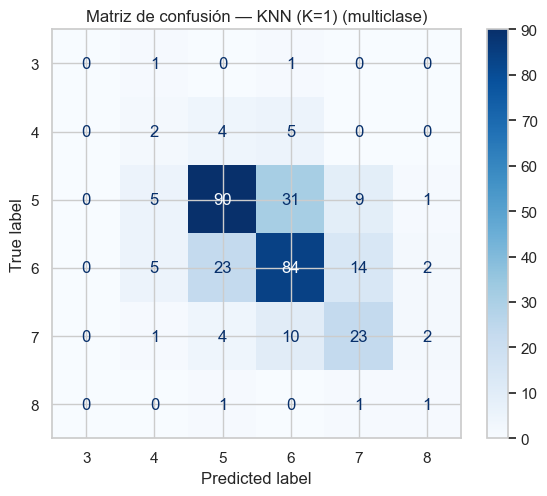

Mejor modelo (F1 macro): KNN (K=1)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.14      0.18      0.16        11
           5       0.74      0.66      0.70       136
           6       0.64      0.66      0.65       128
           7       0.49      0.57      0.53        40
           8       0.17      0.33      0.22         3

    accuracy                           0.62       320
   macro avg       0.36      0.40      0.38       320
weighted avg       0.64      0.62      0.63       320



In [30]:
# 2.4  Matriz de confusión del mejor modelo (según F1 macro)
best_multi_name = summary_multi_df.loc[summary_multi_df['F1 macro'].idxmax(), 'Modelo'] #Selección del Mejor Modelo
y_pred_best_multi = models_multi[best_multi_name] #Recupera las predicciones sobre el conjunto de prueba asociadas al modelo ganador.
labels_multi = sorted(y_multi.unique()) #Obtiene y ordena la lista de etiquetas únicas presentes en el conjunto de datos (por ejemplo, [3, 4, 5, 6, 7, 8]).

fig, ax = plt.subplots(figsize=(6, 5)) #Graficación de la Matriz de Confusión
ConfusionMatrixDisplay.from_predictions( #Crea y renderiza la matriz de confusión directamente comparando los valores reales
    y_test_m, y_pred_best_multi, labels=labels_multi,
    cmap='Blues', ax=ax #Aplica una paleta de tonos azules donde los colores más intensos representan un mayor número de muestras en esa celda.
)
ax.set_title(f'Matriz de confusión — {best_multi_name} (multiclase)')
plt.tight_layout()
plt.show()

print(f'Mejor modelo (F1 macro): {best_multi_name}\n' + '='*60)
print(classification_report(y_test_m, y_pred_best_multi, zero_division=0)) #Muestra el desglose de métricas individuales (Precision, Recall, F1-Score y Support) para cada categoría presente en los datos:

**Conclusiones del Ejercicio 2**

- **Caída de rendimiento:** el desempeño de los cuatro modelos cae claramente frente a la versión binaria (donde el F1 de la clase "Bueno" rondaba 0.50–0.55). Pasar de 2 a 6 clases reduce drásticamente los ejemplos disponibles por clase y las fronteras entre calidades adyacentes (5 vs. 6, 6 vs. 7) son sutiles en términos fisicoquímicos.
- **Clases más difíciles de distinguir:** la matriz de confusión muestra que las clases extremas (3 y 8) casi nunca se aciertan de forma aislada —hay muy pocos ejemplos para generalizar— y se confunden con sus vecinas inmediatas (4 y 7). Las clases centrales 5 y 6 concentran la mayor cantidad *absoluta* de errores simplemente porque son las más numerosas y sus distribuciones de features se solapan bastante entre sí.
- **¿Qué promedio de F1 usar?**
  - `micro` agrega TP/FP/FN de forma global; en un problema multiclase de una sola etiqueta esto equivale numéricamente a la *accuracy*, por lo que queda dominado por las clases mayoritarias y oculta el mal desempeño en las minoritarias.
  - `weighted` pondera cada clase por su soporte, así que también queda dominado por las clases 5 y 6, dando una imagen algo optimista.
  - `macro` calcula el F1 de cada clase por separado y las promedia **sin ponderar**, tratando igual a la clase "3" (10 muestras) que a la clase "5" (681 muestras).
  
  Dado que interesa saber qué tan bien el modelo distingue **todas** las calidades —incluidas las minoritarias, que en un caso real serían los vinos excepcionales o defectuosos— **`macro` es la métrica más adecuada**, aunque sus valores absolutos sean más bajos y "menos favorecedores" que `micro` o `weighted`.

### Ejercicio 3 — Aplicación con dataset propio

Se eligió el dataset **Breast Cancer Wisconsin (Diagnostic)**, disponible directamente en `sklearn.datasets` y publicado originalmente en el repositorio de UCI. Contiene 569 registros y 30 features numéricas derivadas de imágenes digitalizadas de biopsias de tejido mamario, con un target binario: **maligno (0)** o **benigno (1)**. Cumple los requisitos del ejercicio (≥500 registros y ≥5 features) y ofrece un contraste interesante frente al dataset de vinos: es un problema más balanceado y con features mucho más separables.

In [ ]:
# 3.1  Carga del dataset
from sklearn.datasets import load_breast_cancer

data_bc = load_breast_cancer(as_frame=True)
df_bc = data_bc.frame.copy()
features_bc = list(data_bc.feature_names)

print(f'Dataset cargado: {df_bc.shape[0]} registros, {len(features_bc)} features')
print(f'Clases: {list(data_bc.target_names)} -> 0 = {data_bc.target_names[0]}, 1 = {data_bc.target_names[1]}')
print(df_bc['target'].value_counts().rename({0: 'malignant', 1: 'benign'}))
df_bc.head()

Dataset cargado: 569 registros, 30 features
Clases: ['malignant', 'benign'] -> 0 = malignant, 1 = benign
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


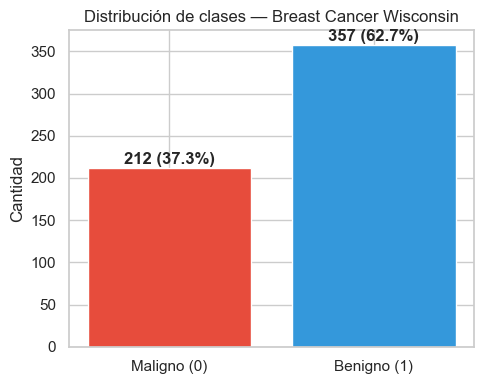

In [ ]:
# 3.2  Balance de clases
fig, ax = plt.subplots(figsize=(5, 4))
counts_bc = df_bc['target'].value_counts().sort_index()
ax.bar(['Maligno (0)', 'Benigno (1)'], counts_bc.values, color=['#e74c3c', '#3498db'])
for i, v in enumerate(counts_bc.values):
    ax.text(i, v + 5, f'{v} ({v/len(df_bc)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribución de clases — Breast Cancer Wisconsin')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [ ]:
# 3.3  Separación features/target y split estratificado 80/20
X_bc = df_bc[features_bc].copy()
y_bc = df_bc['target'].copy()

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bc
)
cv_bc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Train: {X_train_bc.shape[0]} muestras  |  Test: {X_test_bc.shape[0]} muestras')

Train: 455 muestras  |  Test: 114 muestras


In [ ]:
# 3.4  Modelo 1 y 2 — Regresión Logística y Árbol de Decisión
pipe_lr_bc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, class_weight='balanced'))
])
scores_lr_bc = cross_val_score(pipe_lr_bc, X_train_bc, y_train_bc, cv=cv_bc, scoring='f1')
pipe_lr_bc.fit(X_train_bc, y_train_bc)
y_pred_lr_bc = pipe_lr_bc.predict(X_test_bc)

pipe_dt_bc = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                    class_weight='balanced', random_state=RANDOM_STATE))
])
scores_dt_bc = cross_val_score(pipe_dt_bc, X_train_bc, y_train_bc, cv=cv_bc, scoring='f1')
pipe_dt_bc.fit(X_train_bc, y_train_bc)
y_pred_dt_bc = pipe_dt_bc.predict(X_test_bc)

print(f'Logistic Regression — F1 CV: {scores_lr_bc.mean():.4f} ± {scores_lr_bc.std():.4f}')
print(f'Decision Tree       — F1 CV: {scores_dt_bc.mean():.4f} ± {scores_dt_bc.std():.4f}')

Logistic Regression — F1 CV: 0.9805 ± 0.0105
Decision Tree       — F1 CV: 0.9312 ± 0.0128


In [ ]:
# 3.5  Modelo 3 — SVM (comparación de kernels)
svm_results_bc = {}
for kernel in ['linear', 'rbf', 'poly']:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced', random_state=RANDOM_STATE, probability=True))
    ])
    s = cross_val_score(p, X_train_bc, y_train_bc, cv=cv_bc, scoring='f1')
    svm_results_bc[kernel] = s
    print(f'SVM ({kernel:6s}) — F1 CV: {s.mean():.4f} ± {s.std():.4f}')

best_kernel_bc = max(svm_results_bc, key=lambda k: svm_results_bc[k].mean())
pipe_svm_bc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel_bc, class_weight='balanced', random_state=RANDOM_STATE, probability=True))
])
pipe_svm_bc.fit(X_train_bc, y_train_bc)
y_pred_svm_bc = pipe_svm_bc.predict(X_test_bc)
scores_svm_bc = svm_results_bc[best_kernel_bc]
print(f'\nMejor kernel: {best_kernel_bc}')

SVM (linear) — F1 CV: 0.9755 ± 0.0128
SVM (rbf   ) — F1 CV: 0.9788 ± 0.0091
SVM (poly  ) — F1 CV: 0.9471 ± 0.0160

Mejor kernel: rbf


In [ ]:
# 3.6  Modelo 4 — KNN (búsqueda del K óptimo)
k_range_bc = range(1, 31)
k_scores_bc = [
    cross_val_score(
        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))]),
        X_train_bc, y_train_bc, cv=cv_bc, scoring='f1'
    ).mean()
    for k in k_range_bc
]
best_k_bc = k_range_bc[np.argmax(k_scores_bc)]

pipe_knn_bc = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_k_bc))])
scores_knn_bc = cross_val_score(pipe_knn_bc, X_train_bc, y_train_bc, cv=cv_bc, scoring='f1')
pipe_knn_bc.fit(X_train_bc, y_train_bc)
y_pred_knn_bc = pipe_knn_bc.predict(X_test_bc)
print(f'KNN (K={best_k_bc}) — F1 CV: {scores_knn_bc.mean():.4f} ± {scores_knn_bc.std():.4f}')

  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


KNN (K=12) — F1 CV: 0.9757 ± 0.0100


In [ ]:
# 3.7  Análisis comparativo completo
models_bc = {
    'Logistic Regression':     (pipe_lr_bc, y_pred_lr_bc, scores_lr_bc),
    'Decision Tree':           (pipe_dt_bc, y_pred_dt_bc, scores_dt_bc),
    f'SVM ({best_kernel_bc})': (pipe_svm_bc, y_pred_svm_bc, scores_svm_bc),
    f'KNN (K={best_k_bc})':    (pipe_knn_bc, y_pred_knn_bc, scores_knn_bc),
}

summary_bc = []
for name, (pipe, y_pred, s) in models_bc.items():
    summary_bc.append({
        'Modelo': name,
        'F1 CV (mean)': f'{s.mean():.4f}',
        'F1 CV (std)': f'{s.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test_bc, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test_bc, y_pred):.4f}'
    })
summary_bc_df = pd.DataFrame(summary_bc)
summary_bc_df

,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.9805,0.0105,0.9561,0.9645
1,Decision Tree,0.9312,0.0128,0.9035,0.9209
2,SVM (rbf),0.9788,0.0091,0.9649,0.9718
3,KNN (K=12),0.9757,0.0100,0.9737,0.9796


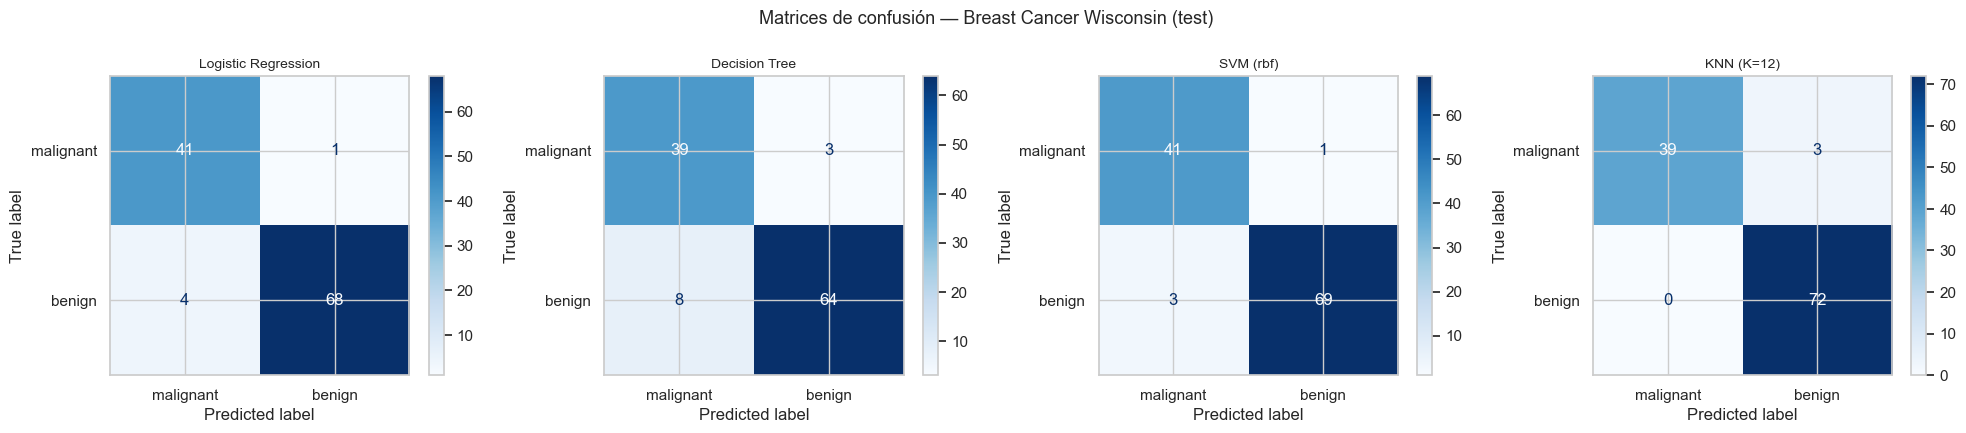

In [ ]:
# 3.8  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, (pipe, y_pred, _)) in zip(axes, models_bc.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_bc, y_pred,
        display_labels=list(data_bc.target_names),
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)
fig.suptitle('Matrices de confusión — Breast Cancer Wisconsin (test)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# 3.9  Classification report del mejor modelo
best_name_bc = max(models_bc, key=lambda k: models_bc[k][2].mean())
print(f'Mejor modelo (F1 CV): {best_name_bc}\n' + '='*60)
print(classification_report(y_test_bc, models_bc[best_name_bc][1], target_names=data_bc.target_names))

Mejor modelo (F1 CV): Logistic Regression
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Hallazgos del Ejercicio 3**

- Con un dataset más balanceado (63 % benigno / 37 % maligno) y con features mucho más separables que las del vino, **los cuatro modelos alcanzan un F1 muy superior** (> 0.90 en todos los casos) al observado en el problema de calidad de vino (F1 ≈ 0.50–0.55).
- Esto confirma que buena parte de las limitaciones observadas en las Secciones 5–9 no son "culpa" de los algoritmos, sino del problema en sí: pocas muestras de la clase positiva, fronteras entre clases poco definidas y features con baja capacidad discriminativa individual.
- Las diferencias de F1 *entre* los cuatro modelos son pequeñas: en un dataset "fácil" y bien comportado como este, la elección del algoritmo importa mucho menos que la calidad de los datos, algo que contrasta con el caso del vino, donde SVM y KNN sí mostraban ventajas claras sobre el resto.
- Regresión Logística y SVM funcionan especialmente bien porque, tras estandarizar, las clases son casi linealmente separables — una situación muy distinta a la del dataset de vinos, donde las clases se solapan considerablemente.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*